In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
R0 = 2
tau_slow = 0.8
alpha = 8e-5 * 2

def r_slow_t(rj, rj0, t):
    return rj - (rj - rj0) * np.exp(-t/tau_slow)

def delta_w_S(rj, T_ext):
    return T_ext * (rj - rj**2 / R0)

def delta_w_T(rj, delta_rj, T_ext):
    return tau_slow / R0 * (2 * rj * delta_rj * (1 - np.exp(- T_ext / tau_slow))
                            - delta_rj**2 / R0 * (1 - np.exp(- 2 * T_ext / tau_slow)))
    
    
    
def delta_w_S_fw(T_ext, F):
    return (0, - T_ext * F**2 / R0, - T_ext * F)
    
def delta_w_T_fw(T_ext, F):
    order_2 = tau_slow / R0 * (2 * F**2 * (1 - np.exp(- T_ext / tau_slow)) - F**2 / 2 * (1 - np.exp(- 2 * T_ext / tau_slow)))
    order_1 = tau_slow / R0 * (2 * F * R0 * (1 - np.exp(- T_ext / tau_slow)))
    
    return (0, order_2, order_1)

    
def delta_w_pre_stim(ri, rj, w, f_stim, T_ext):
    ri = R0 + f_stim
    delta_rj = w * f_stim
    rj = R0 + delta_rj
    # stim =  alpha * ri * rj * (delta_w_S(rj, T_ext) + delta_w_T(rj, delta_rj, T_ext))
    # stim =  alpha * ri * rj * (delta_w_S_fw(T_ext, f_stim, w) + delta_w_T(rj, delta_rj, T_ext))
    
    (s_order3, s_order2, s_order1) = delta_w_S_fw(T_ext, f_stim)
    (t_order3, t_order2, t_order1) = delta_w_T_fw(T_ext, f_stim)
    
    order3 = s_order3 + t_order3
    order2 = s_order2 + t_order2
    order1 = s_order1 + t_order1
    
    stim = alpha * ri * ((order3 * w**3 + order2 * w**2 + order1 * w) * R0 + (order3 * w**3 + order2 * w**2 + order1 * w) * w * f_stim)
    
    # stim =  alpha * ri * rj * (order3 * w**3 + order2 * w**2 + order1 * w)
    

    r_slow = r_slow_t(rj, R0, T_ext)
    ri = rj = R0 
    delta_rj = R0 - r_slow
    
    after_stim = alpha * ri * rj * (delta_w_S(rj, T_ext*3) + delta_w_T(rj, delta_rj, T_ext*3))
    
    return stim + after_stim

# def delta_w_post_stim(ri, rj, w, f_stim, T_ext):
#     ri = R0
#     delta_rj = f_stim
#     rj = R0 + f_stim
#     stim =  alpha * ri * rj * (delta_w_S(rj, T_ext) + delta_w_T(rj, delta_rj, T_ext))

#     r_slow = r_slow_t(rj, R0, T_ext)
#     ri = rj = R0 
#     delta_rj = R0 - r_slow
    
#     after_stim = alpha * ri * rj * (delta_w_S(rj, T_ext*3) + delta_w_T(rj, delta_rj, T_ext*3))
    
#     return stim + after_stim
    

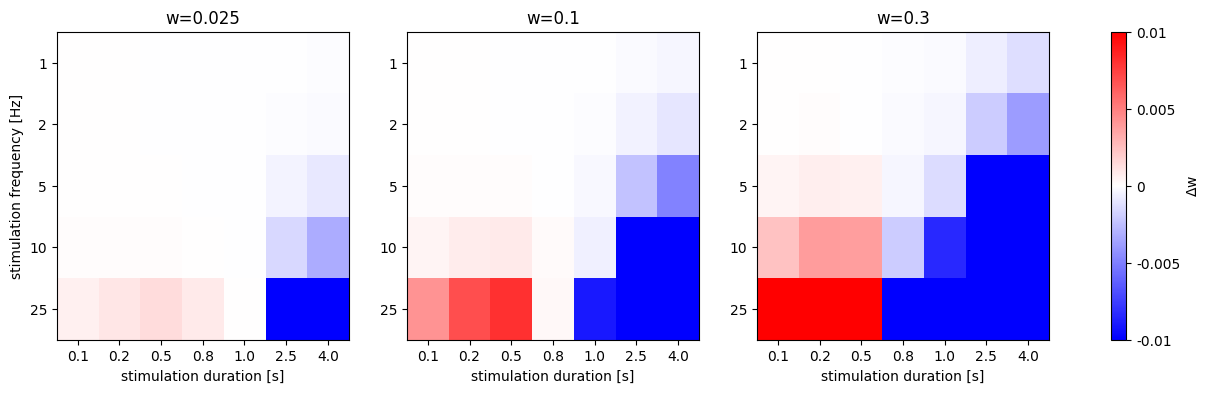

In [13]:
ws = np.array([0.025, 0.1, 0.3])

frequencies = np.array([1, 2, 5, 10, 25])
durations = np.array([0.1, 0.2, 0.5, 0.8, 1, 2.5, 4])

results = np.zeros((ws.size, frequencies.size, durations.size))

for k, w in enumerate(ws):
    for i, F in enumerate(frequencies):
        for j, T in enumerate(durations):
            results[k,i,j] = delta_w_pre_stim(2,2, w, F, T)

lim = 0.01
vmax = lim
vmin = -lim

fig, axs = plt.subplots(1, 3, figsize=(16, 4))

for k, w in enumerate(ws):

    im = axs[k].imshow(
        results[k],
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
        cmap='bwr'
    ) 

    axs[k].set_yticks([i for i, _ in enumerate(frequencies)], [f'{f:.0f}' for f in frequencies])
    axs[k].set_xticks([i for i, _ in enumerate(durations)], [f'{t:.1f}' for t in durations])

    axs[k].set_xlabel('stimulation duration [s]')
    axs[k].set_title(f'w={w}')
axs[0].set_ylabel('stimulation frequency [Hz]')

cbar = fig.colorbar(im, ax=axs, orientation='vertical')
cbar.set_label(r'$\Delta$w')
cbar.set_ticks([-lim,-lim / 2 , 0, lim / 2,lim])
cbar.set_ticklabels([f'{-lim}', f'{-lim/ 2}','0', f'{lim/2}', f'{lim}'])

plt.show()

In [14]:
# ws = np.array([0.025, 0.1, 0.3])

# frequencies = np.array([1, 2, 5, 10, 25])
# durations = np.array([0.1, 0.2, 0.5, 0.8, 1, 2.5, 4])

# results = np.zeros((ws.size, frequencies.size, durations.size))

# for k, w in enumerate(ws):
#     for i, F in enumerate(frequencies):
#         for j, T in enumerate(durations):
#             results[k,i,j] = delta_w_post_stim(2,2, w, F, T)

# lim = 0.01
# vmax = lim
# vmin = -lim

# fig, axs = plt.subplots(1, 3, figsize=(16, 4))

# for k, w in enumerate(ws):

#     im = axs[k].imshow(
#         results[k],
#         aspect='auto',
#         vmin=vmin,
#         vmax=vmax,
#         cmap='bwr'
#     ) 

#     axs[k].set_yticks([i for i, _ in enumerate(frequencies)], [f'{f:.0f}' for f in frequencies])
#     axs[k].set_xticks([i for i, _ in enumerate(durations)], [f'{t:.1f}' for t in durations])

#     axs[k].set_xlabel('stimulation duration [s]')
#     axs[k].set_title(f'w={w}')
# axs[0].set_ylabel('stimulation frequency [Hz]')

# cbar = fig.colorbar(im, ax=axs, orientation='vertical')
# cbar.set_label(r'$\Delta$w')
# cbar.set_ticks([-lim,-lim / 2 , 0, lim / 2,lim])
# cbar.set_ticklabels([f'{-lim}', f'{-lim/ 2}','0', f'{lim/2}', f'{lim}'])

# plt.show()

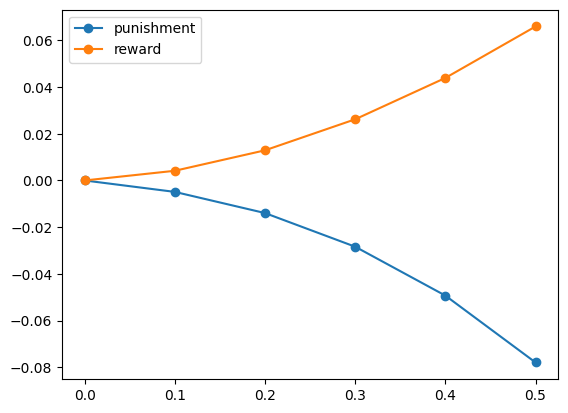

In [15]:
ws = np.arange(0, 0.501, 0.1)
results_p = np.zeros_like(ws)
results_r = np.zeros_like(ws)

for i, w in enumerate(ws):
    results_p[i] = delta_w_pre_stim(2, 2, w, 5, 4)
    results_r[i] = delta_w_pre_stim(2, 2, w, 25, 0.1)
    
plt.plot(ws, results_p, '-o', label='punishment')
plt.plot(ws, results_r, '-o', label='reward')

plt.legend()
plt.show()